# Setup
This section loads libraries and the dataset.

In [ ]:
# Load libraries

# Data
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap

In [ ]:
# Load dataset
df = pd.read_csv("../data/Mall_Customers.xls")

# Check if dataset is loaded
print(f"Dataframe shape: {df.shape}")
print(f"Dataframe columns: {df.columns.to_list()}")
df.head()

Dataframe shape: (200, 5)
Dataframe columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Check data types
print("Dataset information: ")
print(df.info())

# Check for missing values
print("\nMissing values: ")
print(df.isnull().sum())

# Statistics
print("\nDescriptive statistics: ")
print(df.describe())

Dataset information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing values: 
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Descriptive statistics: 
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007       

In [ ]:
# Convert Gender into numerical
df = pd.get_dummies(df, columns=['Gender'], drop_first=True)
df.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False


# Preprocessing
This section prepares the dataset for analysis by cleaning the data of missing values and scaling data to equalize distances between clusters.

In [ ]:
# Define feature columns (Customer information)
features = ["Gender_Male", "Age", "Annual Income (k$)", "Spending Score (1-100)"]

# Extract features for analysis
df_features = df[features]

# Check if features are extracted
print(f"Features shape: {df_features.shape}")
print(f"Features columns: {df_features.columns.to_list()}")
df_features.head()

Features shape: (200, 4)
Features columns: ['Gender_Male', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


,Gender_Male,Age,Annual Income (k$),Spending Score (1-100)
0,True,19,15,39
1,True,21,15,81
2,False,20,16,6
3,False,23,16,77
4,False,31,17,40


In [ ]:
# Scale features with StandardScaler
features_to_be_scaled = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features[features_to_be_scaled])
df_scaled = pd.DataFrame(df_scaled, columns=features_to_be_scaled)
df_scaled["Gender_Male"] = df_features["Gender_Male"]

# Check if features are scaled
print(f"Scaled features shape: {df_scaled.shape}")
print(f"Scaled features columns: {df_scaled.columns.to_list()}")
df_scaled.head()

Scaled features shape: (200, 4)
Scaled features columns: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']


,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,True
1,-1.281035,-1.738999,1.195704,True
2,-1.352802,-1.700830,-1.715913,False
3,-1.137502,-1.700830,1.040418,False
4,-0.563369,-1.662660,-0.395980,False


# Clustering Analysis
This section seperates the dataset into multiple cluster and analyzes customer behaviour based off of our clusters.

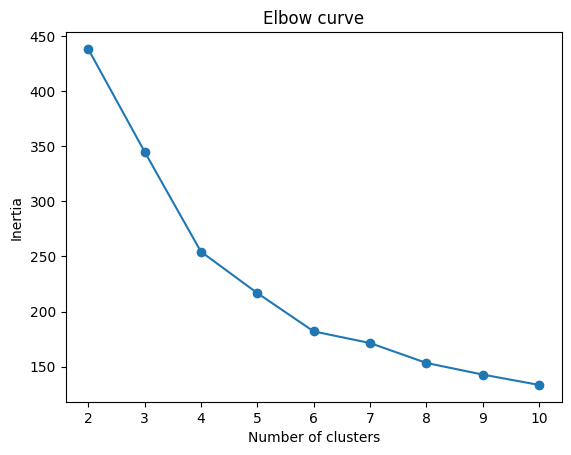

In [ ]:
# Implement elbow method
inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow curve')
plt.show()

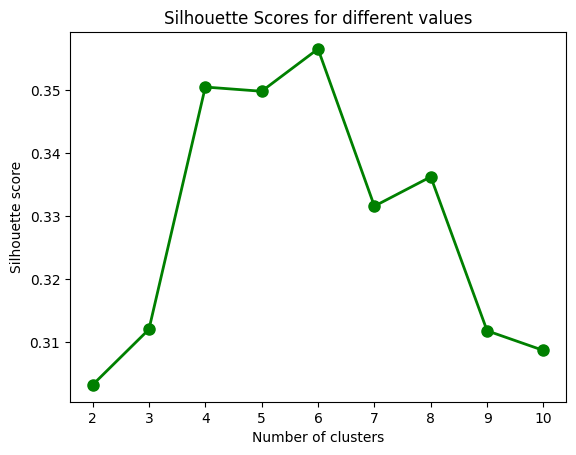

In [ ]:
# Calculate silhouette scores for K=2 to K=10
silhouette_scores = []

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(df_scaled)
  labels = kmeans.labels_
  silhouette_scores.append(silhouette_score(df_scaled, labels))

# Plot silhouette scores
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores for different values')
plt.show()

We decided to pick K=6 because the elbow curve shows a significant change in interia and the highest silhouette score.

In [ ]:
# Fit K-Means model
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans.fit(df_scaled)
cluster_labels = kmeans.labels_

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts())


Cluster distribution:
Cluster
0    45
1    39
5    38
3    34
4    23
2    21
Name: count, dtype: int64


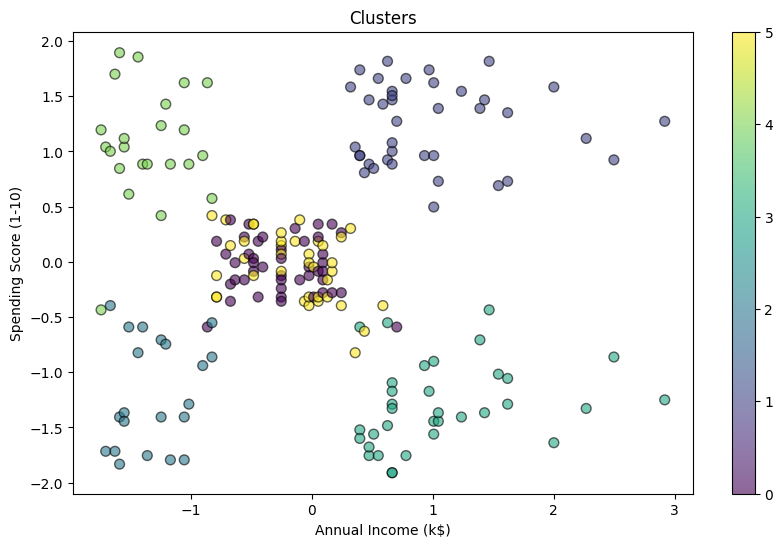

In [ ]:
# Visualize clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_scaled['Annual Income (k$)'],
                      df_scaled['Spending Score (1-100)'], c=cluster_labels,
                      cmap='viridis', alpha=0.6, edgecolors='k', s=50)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-10)')
plt.title('Clusters')
plt.colorbar(scatter)
plt.show()

In [ ]:
# Analyze mean customer information for each cluster
cluster_spending = df.groupby('Cluster')[features_to_be_scaled].mean().reset_index()

print(f"\nMean spending score for each cluster:")
print(cluster_spending)

# Analyze gender distribution for each cluster
cluster_gender = df.groupby('Cluster')['Gender_Male'].value_counts(normalize=True).unstack().reset_index()

print(f"\nGender distribution for each cluster:")
print(cluster_gender)


Mean spending score for each cluster:
   Cluster        Age  Annual Income (k$)  Spending Score (1-100)
0        0  56.333333           54.266667               49.066667
1        1  32.692308           86.538462               82.128205
2        2  45.523810           26.285714               19.380952
3        3  41.264706           88.500000               16.764706
4        4  25.000000           25.260870               77.608696
5        5  27.000000           56.657895               49.131579

Gender distribution for each cluster:
Gender_Male  Cluster     False      True
0                  0  0.577778  0.422222
1                  1  0.538462  0.461538
2                  2  0.619048  0.380952
3                  3  0.411765  0.588235
4                  4  0.565217  0.434783
5                  5  0.657895  0.342105


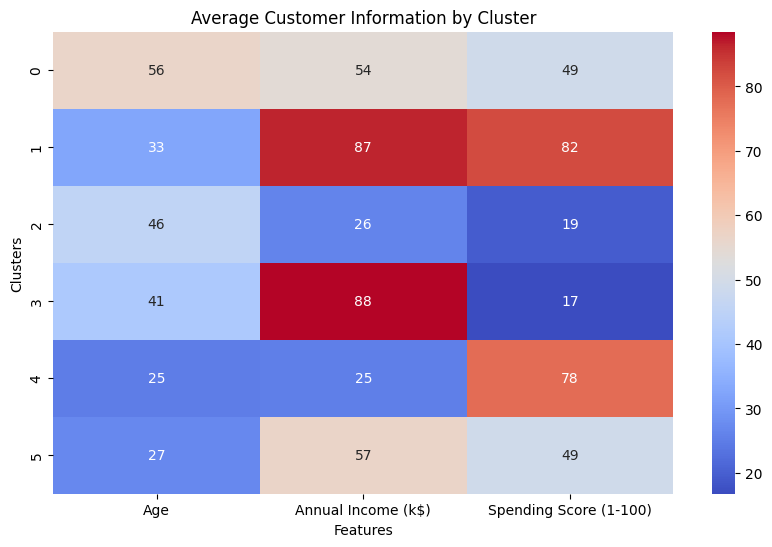

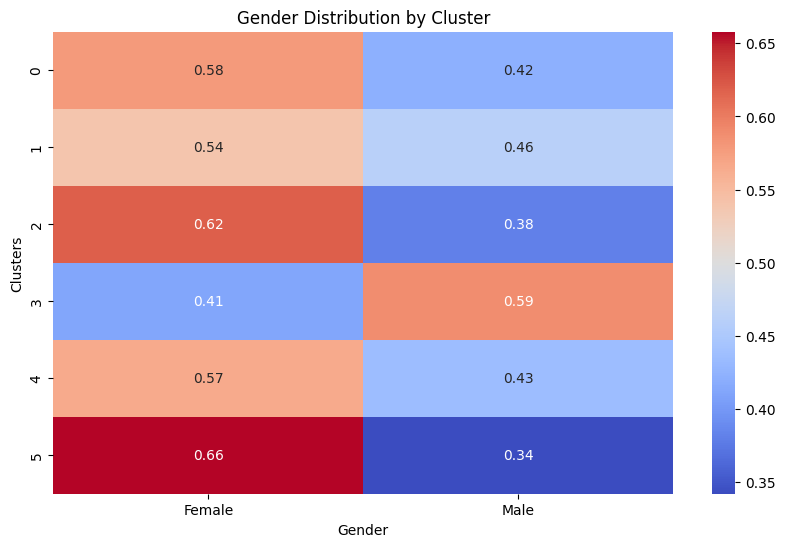

In [ ]:
# Create heatmap for cluster means
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_spending[features_to_be_scaled], annot=True, cmap='coolwarm')
plt.xlabel('Features')
plt.ylabel('Clusters')
plt.title('Average Customer Information by Cluster')
plt.show()

# Create heatmap for gender distribution
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_gender.iloc[:, 1:], annot=True, cmap='coolwarm')
plt.xlabel('Gender')
plt.ylabel('Clusters')
plt.title('Gender Distribution by Cluster')
plt.xticks([0.5, 1.5], ['Female', 'Male'])
plt.show()

# Cluster Characteristics

Cluster 0: Slightly Female (58%), middle age (56 average age), middle income (54k annual income), medium spender (49 score)

Cluster 1: Slightly Female (54%), middle age (33 average age), high income (87k annual income), high spender (82 score)

Cluster 2: Mostly Female (62%), middle age (46 average age), low income (19k annual income), very low spender (19 score)

Cluster 3: Slightly Male (59%), middle age (41 average age), high income (88k annual income), very low spender (17 score)

Cluster 4: Slightly Female (57%), young (25 average age), low income (17k annual income), high spender (79 score)

Cluster 5: Mostly Female (66%), young (27 average age), middle income (57k annual income), medium spender (49 score)

# Cluster Names

Cluster 0: We named this cluster **Moderate Shopper** because the means do not suggest that this demographic has much more potential to spend more than the listed characteristics.

Cluster 1: We named this cluster **Trendy Customer** because these customers statistics suggest that this group spends based on trends because of their income, age, and spending scores.

Cluster 2: We named this cluster **Budget Female Spender** because of their low income correlating with their low spending score.

Cluster 3: We named this cluster **Stingy Buyers** because their spending score of 17 has the potential to be higher because of their annual income of $88k per year.

Cluster 4: We named this cluster **Young Consumer** because of their young age, low income, but high spending score.

Cluster 5: We named this cluster **Young Female Shopper** because of their young age and uneven distribution leaning towards women.

# PCA Decomposition

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure we have a clean numeric matrix
X = df_scaled.values  # (n_samples, n_features)
y = cluster_labels    # cluster labels from your KMeans


In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_
print("PCA explained variance ratio (PC1, PC2):", explained)
print("Cumulative explained variance (PC1+PC2):", explained.sum())

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = y
pca_df.head()


PCA explained variance ratio (PC1, PC2): [0.4095285 0.3081674]
Cumulative explained variance (PC1+PC2): 0.7176959022847653


,PC1,PC2,Cluster
0,-0.600438,-1.737179,4
1,-1.649886,-1.789124,4
2,0.315381,-1.692772,2
3,-1.477989,-1.781317,4
4,-0.060545,-1.678691,2


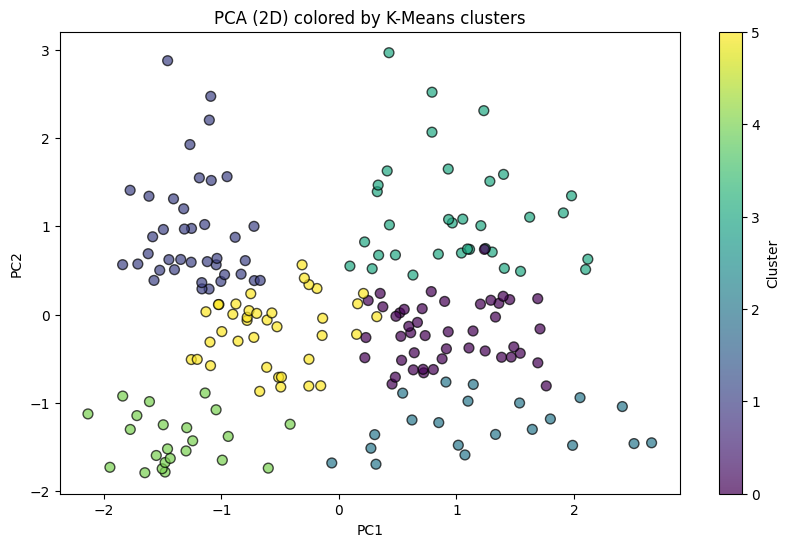

In [ ]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Cluster"], cmap="viridis", alpha=0.7, edgecolors="k", s=50)
plt.title("PCA (2D) colored by K-Means clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc, label="Cluster")
plt.show()


# t-SNE

In [ ]:
# t-SNE can be slow; these settings are safe for 200 rows (Mall Customers)
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1", "TSNE2"])
tsne_df["Cluster"] = y
tsne_df.head()


,TSNE1,TSNE2,Cluster
0,3.743712,-3.852591,4
1,6.597162,-5.718558,4
2,-0.464608,4.466268,2
3,7.222599,-4.595264,4
4,0.096499,2.350220,2


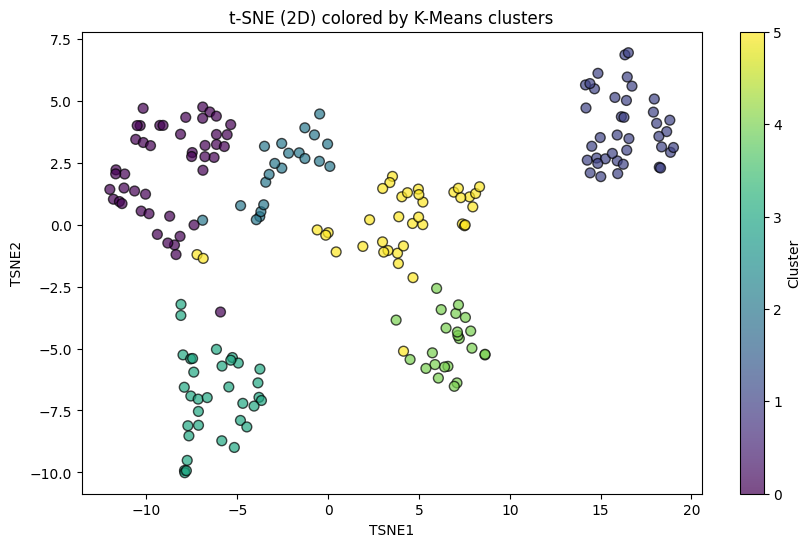

In [ ]:
plt.figure(figsize=(10, 6))
sc = plt.scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], c=tsne_df["Cluster"], cmap="viridis", alpha=0.7, edgecolors="k", s=50)
plt.title("t-SNE (2D) colored by K-Means clusters")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.colorbar(sc, label="Cluster")
plt.show()


# UMAP

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


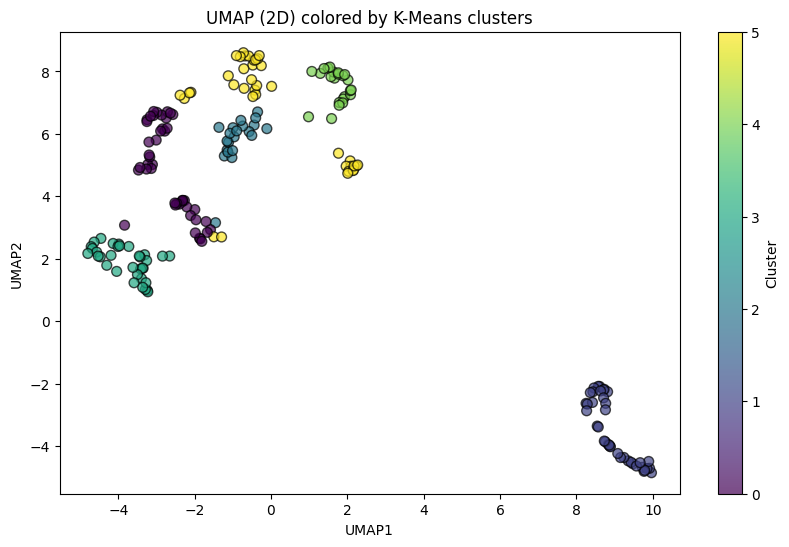

In [ ]:
try:
    import umap.umap_ as umap

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X)

    umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
    umap_df["Cluster"] = y

    plt.figure(figsize=(10, 6))
    sc = plt.scatter(umap_df["UMAP1"], umap_df["UMAP2"], c=umap_df["Cluster"], cmap="viridis", alpha=0.7, edgecolors="k", s=50)
    plt.title("UMAP (2D) colored by K-Means clusters")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")
    plt.colorbar(sc, label="Cluster")
    plt.show()

except Exception as e:
    print("UMAP not available (skip). Error:", e)


The data seems to exhibit a non-lineare structure because t-SNE and UMAP were more successful than PCA at seperating the clusters.

We would recommend t-SNE to business executives because executives can better tell each customer segment than PCA.

# Anomaly Detection

In [ ]:
from sklearn.ensemble import IsolationForest
contamination_list = [0.01, 0.03, 0.05]  # 3 different values (required)
results = []

for c in contamination_list:
    iso = IsolationForest(
        n_estimators=300,
        contamination=c,
        random_state=42
    )
    preds = iso.fit_predict(X)  # -1 = anomaly, +1 = normal
    n_anom = int((preds == -1).sum())

    # Which clusters do anomalies come from?
    temp = df.copy()
    temp["AnomalyFlag"] = (preds == -1).astype(int)
    by_cluster = temp.groupby("Cluster")["AnomalyFlag"].sum().sort_values(ascending=False)

    results.append({
        "contamination": c,
        "n_anomalies": n_anom,
        "anomalies_by_cluster": by_cluster.to_dict()
    })

pd.DataFrame(results)


,contamination,n_anomalies,anomalies_by_cluster
0,0.01,2,"{1: 1, 2: 1, 0: 0, 3: 0, 4: 0, 5: 0}"
1,0.03,6,"{2: 3, 1: 1, 4: 1, 3: 1, 0: 0, 5: 0}"
2,0.05,10,"{1: 3, 2: 3, 4: 2, 3: 2, 0: 0, 5: 0}"


In [ ]:
FINAL_CONTAMINATION = 0.03  # change this after you review the table above

iso_final = IsolationForest(
    n_estimators=300,
    contamination=FINAL_CONTAMINATION,
    random_state=42
)

preds_final = iso_final.fit_predict(X)   # -1 anomaly, +1 normal
scores_final = iso_final.decision_function(X)  # lower = more anomalous

df["Is_Anomaly"] = (preds_final == -1)
df["Anomaly_Score"] = scores_final

print("Final contamination:", FINAL_CONTAMINATION)
print("Number of anomalies:", df["Is_Anomaly"].sum())
df[["Cluster", "Is_Anomaly", "Anomaly_Score"]].head()


Final contamination: 0.03
Number of anomalies: 6


,Cluster,Is_Anomaly,Anomaly_Score
0,4,False,0.006615
1,4,False,0.021546
2,2,True,-0.034267
3,4,False,0.076028
4,2,False,0.081092


In [ ]:
# Show the most extreme anomalies (lowest score)
anom_examples = df[df["Is_Anomaly"]].sort_values("Anomaly_Score")

cols_to_show = [
    "Gender_Male", "Age", "Annual Income (k$)", "Spending Score (1-100)",
    "Cluster", "Anomaly_Score"
]

anom_examples[cols_to_show]


,Gender_Male,Age,Annual Income (k$),Spending Score (1-100),Cluster,Anomaly_Score
199,True,30,137,83,1,-0.038348
2,False,20,16,6,2,-0.034267
198,True,32,137,18,3,-0.031265
8,True,64,19,3,2,-0.017314
10,True,67,19,14,2,-0.008267


In [ ]:
anom_by_cluster = df[df["Is_Anomaly"]].groupby("Cluster").size().sort_values(ascending=False)
anom_by_cluster


,0
Cluster,
2,3
1,1
3,1
4,1


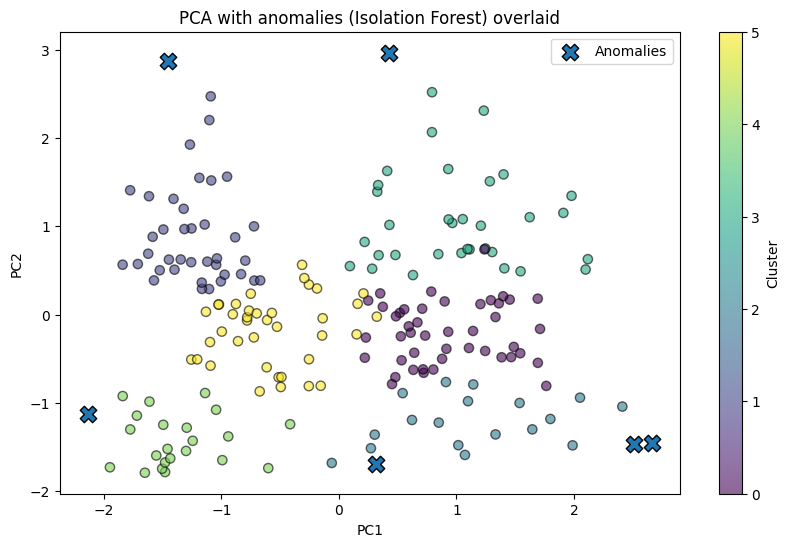

In [ ]:
# Reuse PCA embeddings from Part 2 (pca_df) and flag anomalies
pca_plot = pca_df.copy()
pca_plot["Is_Anomaly"] = df["Is_Anomaly"].values

plt.figure(figsize=(10, 6))

# Normal points (colored by cluster)
normal = pca_plot[~pca_plot["Is_Anomaly"]]
sc = plt.scatter(
    normal["PC1"], normal["PC2"],
    c=normal["Cluster"], cmap="viridis",
    alpha=0.6, edgecolors="k", s=45
)

# Anomalies as X markers
anom = pca_plot[pca_plot["Is_Anomaly"]]
plt.scatter(
    anom["PC1"], anom["PC2"],
    marker="X", s=140, edgecolors="k",
    label="Anomalies"
)

plt.title("PCA with anomalies (Isolation Forest) overlaid")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc, label="Cluster")
plt.legend()
plt.show()


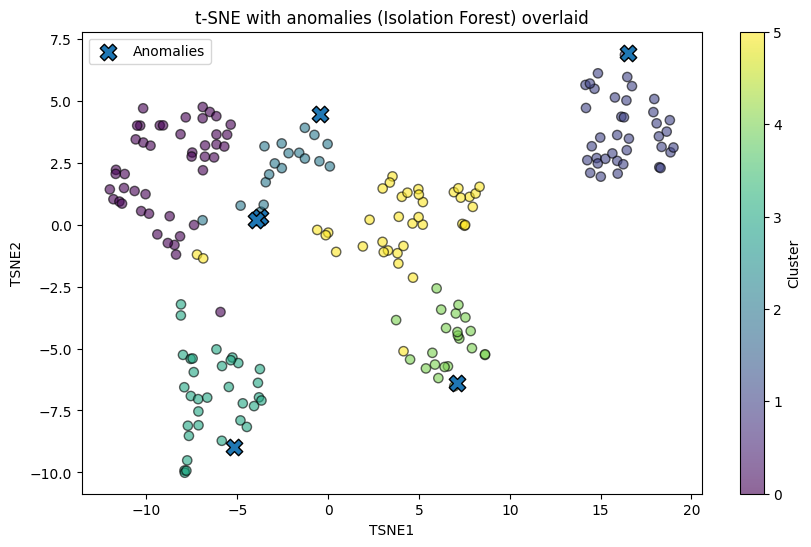

In [ ]:
tsne_plot = tsne_df.copy()
tsne_plot["Is_Anomaly"] = df["Is_Anomaly"].values

plt.figure(figsize=(10, 6))

normal = tsne_plot[~tsne_plot["Is_Anomaly"]]
sc = plt.scatter(
    normal["TSNE1"], normal["TSNE2"],
    c=normal["Cluster"], cmap="viridis",
    alpha=0.6, edgecolors="k", s=45
)

anom = tsne_plot[tsne_plot["Is_Anomaly"]]
plt.scatter(
    anom["TSNE1"], anom["TSNE2"],
    marker="X", s=140, edgecolors="k",
    label="Anomalies"
)

plt.title("t-SNE with anomalies (Isolation Forest) overlaid")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.colorbar(sc, label="Cluster")
plt.legend()
plt.show()


3 types of anomalies:
- VIP Customer (High income and high spending score)
- Low Spender (Low income and low spending score)
- Potential Errors (Income and Spending Score negatively correlate)

Strategies:
- Target Marketing: Give high-spending customers special offers or loyalty rewards
- Data Cleaning: Low-spending, high-income customers warrant investigation to see if spending behaviour is legitimate